# KV Cache Demo Notebook

`llm/kv_cache.md` supplement. Runs on numpy and the standard library only — no GPU or large models required.

**Table of Contents**
1. Why KV Cache Is Needed (Attention Basics)
2. Memory Size Calculation
3. HuggingFace `DynamicCache` / `StaticCache` Behavior Simulation
4. Memory Comparison: MHA / GQA / MQA
5. PagedAttention Block Management Simulation
6. Prefix Caching Hash Chain
7. Effect of KV Cache Quantization

In [1]:
import numpy as np
import time
import hashlib
import warnings
from dataclasses import dataclass, field
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120
print("imports OK")

imports OK


---
## 1. Why KV Cache Is Needed

### 1-1. Basics of Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right) V$$

In autoregressive decoding, when generating one new token at step $t$:
- $Q_t$: one new token (shape: `[1, d]`)
- $K_{0..t}$, $V_{0..t}$: all past tokens (shape: `[t+1, d]`)

**Without KV Cache** → recompute $K$, $V$ for all tokens every step  
**With KV Cache** → compute only $K_t$, $V_t$ for the new token and append to cache

In [2]:
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def attention(Q, K, V):
    """Scaled Dot-Product Attention.  Q:[q,d]  K,V:[s,d]"""
    d = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d)   # [q, s]
    weights = softmax(scores)        # [q, s]
    return weights @ V               # [q, d]

# ---------- Without KV Cache ----------
def decode_without_cache(X, Wq, Wk, Wv, n_steps):
    """X: input embedding [context, d]. Generate n_steps tokens"""
    tokens = X.copy()
    ops = 0
    for t in range(n_steps):
        Q = tokens[-1:] @ Wq          # latest token only
        K = tokens @ Wk               # recompute all tokens every step
        V = tokens @ Wv               # recompute all tokens every step
        out = attention(Q, K, V)
        ops += len(tokens)             # number of rows recomputed for K, V
        new_token = out               # simplified: use output directly as next input
        tokens = np.vstack([tokens, new_token])
    return ops

# ---------- With KV Cache ----------
def decode_with_cache(X, Wq, Wk, Wv, n_steps):
    """Same processing using KV cache"""
    tokens = X.copy()
    K_cache = tokens @ Wk             # precompute for initial context
    V_cache = tokens @ Wv
    ops = 0
    for t in range(n_steps):
        new_token = tokens[-1:]
        Q   = new_token @ Wq
        K_t = new_token @ Wk          # compute only 1 token
        V_t = new_token @ Wv
        K_cache = np.vstack([K_cache, K_t])   # append to cache
        V_cache = np.vstack([V_cache, V_t])
        out = attention(Q, K_cache, V_cache)
        ops += 1                       # K, V computation is always 1 row
        tokens = np.vstack([tokens, out])
    return ops

# --- Simulation ---
np.random.seed(42)
d = 64
n_context = 32
n_steps   = 200
X  = np.random.randn(n_context, d)
Wq = np.random.randn(d, d) * 0.1
Wk = np.random.randn(d, d) * 0.1
Wv = np.random.randn(d, d) * 0.1

ops_no_cache = decode_without_cache(X, Wq, Wk, Wv, n_steps)
ops_cache    = decode_with_cache   (X, Wq, Wk, Wv, n_steps)

print(f"Without KV Cache: total K/V recomputed rows = {ops_no_cache:,}")
print(f"With KV Cache:    total K/V recomputed rows = {ops_cache:,}")
print(f"Reduction: {(1 - ops_cache/ops_no_cache)*100:.1f}%")

Without KV Cache: total K/V recomputed rows = 26,300
With KV Cache:    total K/V recomputed rows = 200
Reduction: 99.2%


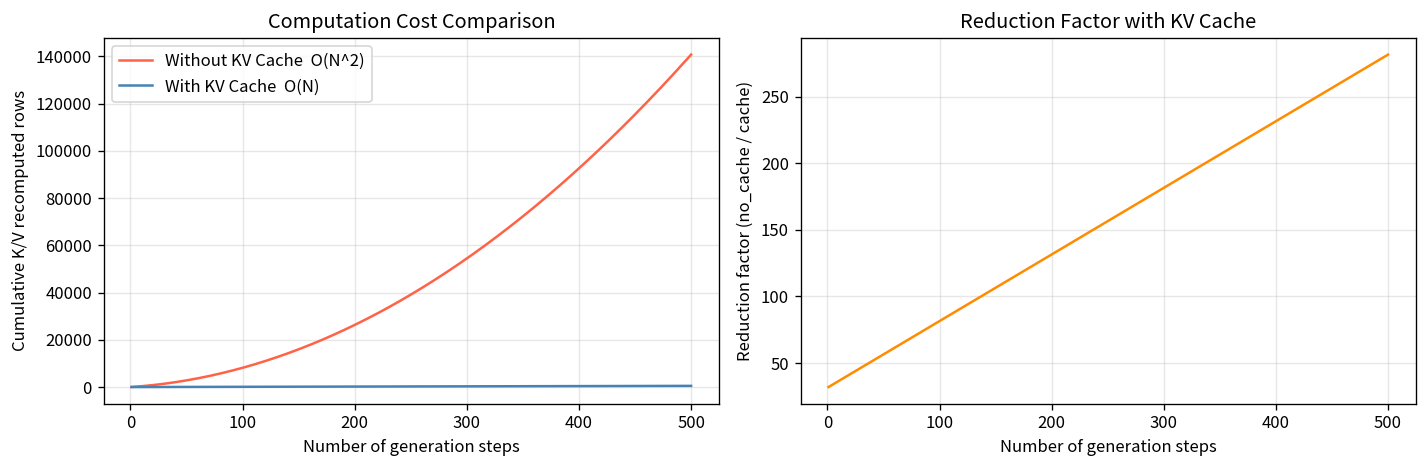

Reduction factor at 500 steps: 282x


In [3]:
# Visualize computation cost by number of generation steps: with vs without KV Cache
steps_list = list(range(1, 501))
ops_no  = [sum(n_context + t for t in range(s)) for s in steps_list]
ops_yes = steps_list  # 1 row per step

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps_list, ops_no,  label="Without KV Cache  O(N^2)", color="tomato")
axes[0].plot(steps_list, ops_yes, label="With KV Cache  O(N)",      color="steelblue")
axes[0].set_xlabel("Number of generation steps")
axes[0].set_ylabel("Cumulative K/V recomputed rows")
axes[0].set_title("Computation Cost Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ratio = [no/yes for no, yes in zip(ops_no, ops_yes)]
axes[1].plot(steps_list, ratio, color="darkorange")
axes[1].set_xlabel("Number of generation steps")
axes[1].set_ylabel("Reduction factor (no_cache / cache)")
axes[1].set_title("Reduction Factor with KV Cache")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Reduction factor at 500 steps: {ratio[-1]:.0f}x")

---
## 2. Memory Size Calculation

KV cache bytes per layer:

$$\text{bytes} = 2 \times \text{seq\_len} \times n_{kv\_heads} \times d_{head} \times \text{dtype\_bytes}$$

Actual memory usage = (above) × number of layers × batch size.

In [4]:
def kv_cache_bytes(seq_len, num_kv_heads, head_dim, num_layers, dtype_bytes=2):
    """Total KV cache size across all layers (bytes)"""
    return 2 * seq_len * num_kv_heads * head_dim * num_layers * dtype_bytes

models = {
    "LLaMA-3 8B  (GQA)":  dict(num_kv_heads=8,  head_dim=128, num_layers=32),
    "LLaMA-3 70B (GQA)":  dict(num_kv_heads=8,  head_dim=128, num_layers=80),
    "LLaMA-2 7B  (MHA)":  dict(num_kv_heads=32, head_dim=128, num_layers=32),
    "Mistral 7B  (GQA)":  dict(num_kv_heads=8,  head_dim=128, num_layers=32),
    "GPT-2 Small (MHA)":  dict(num_kv_heads=12, head_dim=64,  num_layers=12),
}

seq_len    = 4096
batch_size = 8
dtype_bytes = 2  # bfloat16

print(f"{'Model':<25} {'1 token (KB)':>12} {'4096 tokens (MB)':>18} "
      f"{'batch=8 (GB)':>14}")
print("-" * 72)
for name, cfg in models.items():
    per_token  = kv_cache_bytes(1,       **cfg, dtype_bytes=dtype_bytes)
    full_seq   = kv_cache_bytes(seq_len, **cfg, dtype_bytes=dtype_bytes)
    full_batch = full_seq * batch_size
    print(f"{name:<25} {per_token/1024:>12.1f} {full_seq/1024**2:>18.1f} "
          f"{full_batch/1024**3:>14.2f}")

Model                     1 token (KB)   4096 tokens (MB)   batch=8 (GB)
------------------------------------------------------------------------
LLaMA-3 8B  (GQA)                128.0              512.0           4.00
LLaMA-3 70B (GQA)                320.0             1280.0          10.00
LLaMA-2 7B  (MHA)                512.0             2048.0          16.00
Mistral 7B  (GQA)                128.0              512.0           4.00
GPT-2 Small (MHA)                 36.0              144.0           1.12


---
## 3. HuggingFace DynamicCache / StaticCache Behavior Simulation

Two caching strategies implemented in transformers' `cache_utils.py`:

| | DynamicCache | StaticCache |
|---|---|---|
| Implementation | Re-allocates each step via `torch.cat` | Index-writes into a pre-allocated tensor |
| Memory | Uses only what is needed | Allocates max_seq_len upfront |
| torch.compile | Not supported (shape changes) | **Supported** (shape is fixed) |
| Use case | Development / debugging | Production inference (TorchScript, torch.compile) |

`DynamicLayer.update()` (mimicking the transformers implementation):
```python
self.key_cache[layer_idx] = torch.cat([self.key_cache[layer_idx], key_states], dim=-2)
```

`StaticLayer.update()` (mimicking the transformers implementation):
```python
k_out[..., cache_position, :] = key_states  # index write
```

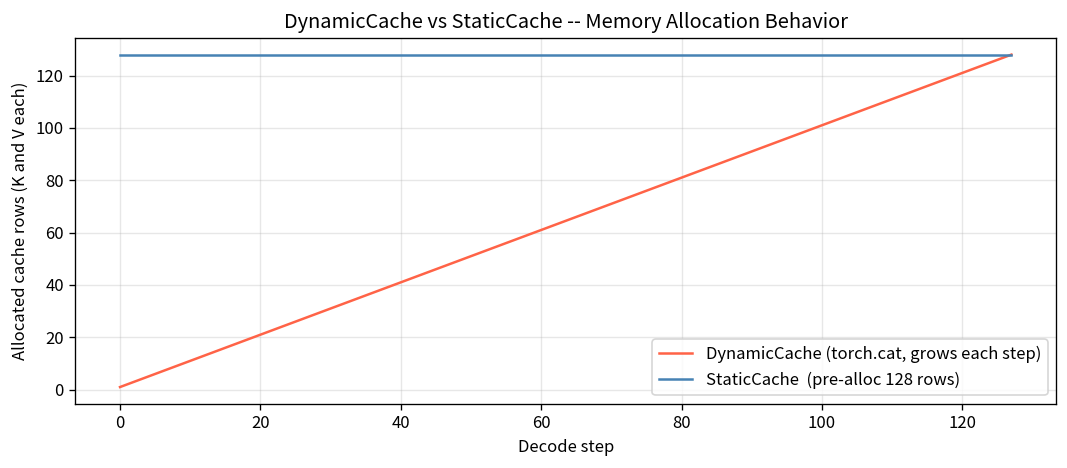

DynamicCache: new array each step -> not torch.compile-compatible, but no waste
StaticCache : fixed shape -> torch.compile-compatible, suitable for production inference


In [5]:
class DynamicLayerSim:
    """Simulate one layer of DynamicCache (torch.cat approach)"""
    def __init__(self):
        self.key_cache = np.empty((0, 64))   # shape: [seq, d]
        self.val_cache = np.empty((0, 64))
        self.alloc_log = []                  # (step, allocated_rows)

    def update(self, key, val, step):
        # Create a new array each step -> re-allocation
        self.key_cache = np.vstack([self.key_cache, key])
        self.val_cache = np.vstack([self.val_cache, val])
        self.alloc_log.append((step, len(self.key_cache)))  # allocated rows so far
        return self.key_cache, self.val_cache


class StaticLayerSim:
    """Simulate one layer of StaticCache (pre-allocation approach)"""
    def __init__(self, max_seq_len, d=64):
        self.max_seq_len = max_seq_len
        # Allocate max_seq_len upfront (equivalent to torch.zeros)
        self.key_cache = np.zeros((max_seq_len, d))
        self.val_cache = np.zeros((max_seq_len, d))
        self.alloc_log = []

    def update(self, key, val, step):
        # Index write only -- no re-allocation
        self.key_cache[step] = key
        self.val_cache[step] = val
        self.alloc_log.append((step, self.max_seq_len))    # always max_seq_len
        return self.key_cache[:step+1], self.val_cache[:step+1]


# --- Simulation ---
MAX_SEQ = 128
d = 64
np.random.seed(0)

dyn = DynamicLayerSim()
sta = StaticLayerSim(max_seq_len=MAX_SEQ, d=d)

for step in range(MAX_SEQ):
    k = np.random.randn(1, d) * 0.1
    v = np.random.randn(1, d) * 0.1
    dyn.update(k, v, step)
    sta.update(k[0], v[0], step)

steps    = [s for s, _ in dyn.alloc_log]
dyn_rows = [r for _, r in dyn.alloc_log]
sta_rows = [r for _, r in sta.alloc_log]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, dyn_rows, label="DynamicCache (torch.cat, grows each step)", color="tomato")
ax.plot(steps, sta_rows, label=f"StaticCache  (pre-alloc {MAX_SEQ} rows)", color="steelblue")
ax.set_xlabel("Decode step")
ax.set_ylabel("Allocated cache rows (K and V each)")
ax.set_title("DynamicCache vs StaticCache -- Memory Allocation Behavior")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("DynamicCache: new array each step -> not torch.compile-compatible, but no waste")
print("StaticCache : fixed shape -> torch.compile-compatible, suitable for production inference")

---
## 4. Memory Comparison: MHA / GQA / MQA

| Method | Number of KV Heads | Characteristics |
|---|---|---|
| MHA (Multi-Head Attention) | Same as Q | Standard. Largest KV cache |
| GQA (Grouped-Query Attention) | 1/G of Q | LLaMA-3, Mistral, etc. Middle ground |
| MQA (Multi-Query Attention) | 1 | Smallest. Quality trade-off |

KV cache bytes scale with `num_kv_heads`, so GQA/MQA achieve significant reductions.

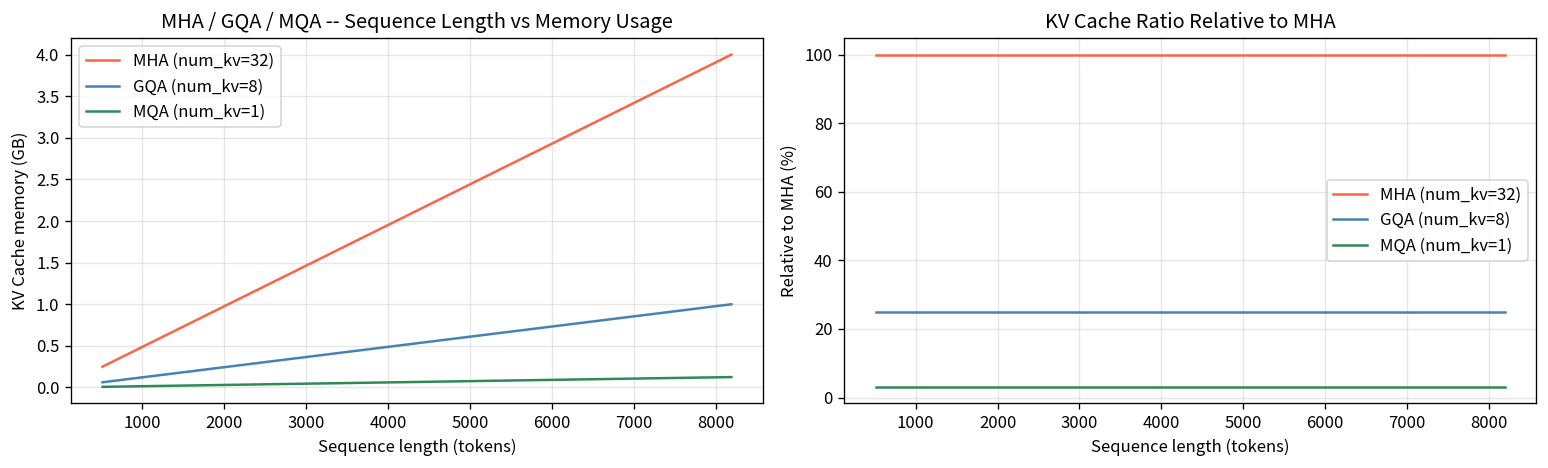

Memory comparison at 8192 tokens (LLaMA-3 8B equivalent):
  MHA (num_kv=32)     : 4.00 GB  (100.0% of MHA)
  GQA (num_kv=8)      : 1.00 GB  (25.0% of MHA)
  MQA (num_kv=1)      : 0.12 GB  (3.1% of MHA)


In [6]:
# Compare using LLaMA-3 8B base parameters
num_q_heads = 32
head_dim    = 128
num_layers  = 32
dtype_bytes = 2   # bfloat16
seq_lengths = list(range(512, 8193, 512))

def kv_bytes(seq_len, num_kv_heads):
    return 2 * seq_len * num_kv_heads * head_dim * num_layers * dtype_bytes

configs = {
    "MHA (num_kv=32)": num_q_heads,
    "GQA (num_kv=8)" : 8,
    "MQA (num_kv=1)" : 1,
}

colors = {"MHA (num_kv=32)": "tomato", "GQA (num_kv=8)": "steelblue", "MQA (num_kv=1)": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, n_kv in configs.items():
    mem_gb = [kv_bytes(s, n_kv) / 1024**3 for s in seq_lengths]
    axes[0].plot(seq_lengths, mem_gb, label=label, color=colors[label])

axes[0].set_xlabel("Sequence length (tokens)")
axes[0].set_ylabel("KV Cache memory (GB)")
axes[0].set_title("MHA / GQA / MQA -- Sequence Length vs Memory Usage")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reduction ratio relative to MHA
mha_mem = [kv_bytes(s, num_q_heads) for s in seq_lengths]
for label, n_kv in configs.items():
    ratio = [kv_bytes(s, n_kv) / mha_mem[i] for i, s in enumerate(seq_lengths)]
    axes[1].plot(seq_lengths, [r * 100 for r in ratio], label=label, color=colors[label])

axes[1].set_xlabel("Sequence length (tokens)")
axes[1].set_ylabel("Relative to MHA (%)")
axes[1].set_title("KV Cache Ratio Relative to MHA")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Memory comparison at 8192 tokens (LLaMA-3 8B equivalent):")
for label, n_kv in configs.items():
    gb = kv_bytes(8192, n_kv) / 1024**3
    ratio = n_kv / num_q_heads * 100
    print(f"  {label:<20}: {gb:.2f} GB  ({ratio:.1f}% of MHA)")

---
## 5. PagedAttention Block Management Simulation

vLLM's PagedAttention divides GPU memory into **fixed-size blocks**,  
allowing multiple requests to share memory without fragmentation.

```
Physical block pool: [B0][B1][B2][B3][B4][B5]...

Request A (seq_len=20, block_size=16):
  -> physical block B2 (tokens 0-15), B5 (tokens 16-19)

Request B (seq_len=10, block_size=16):
  -> physical block B1 (tokens 0-9)
```

vLLM's `FreeKVCacheBlockQueue` uses a doubly-linked list for O(1) free and acquire.  
Each block has a `ref_count` used for block sharing in Prefix Caching.

Initial free blocks: 12/12
After req A allocation: free 9
After req B allocation: free 7
After req C allocation: free 3
After req A freed:      free 6
After req D allocation: free 3

Operation log:
  alloc req=A: blocks [0, 1, 2]
  alloc req=B: blocks [3, 4]
  alloc req=C: blocks [5, 6, 7, 8]
  free  req=A: blocks [0, 1, 2] -> free pool
  alloc req=D: blocks [9, 10, 11]


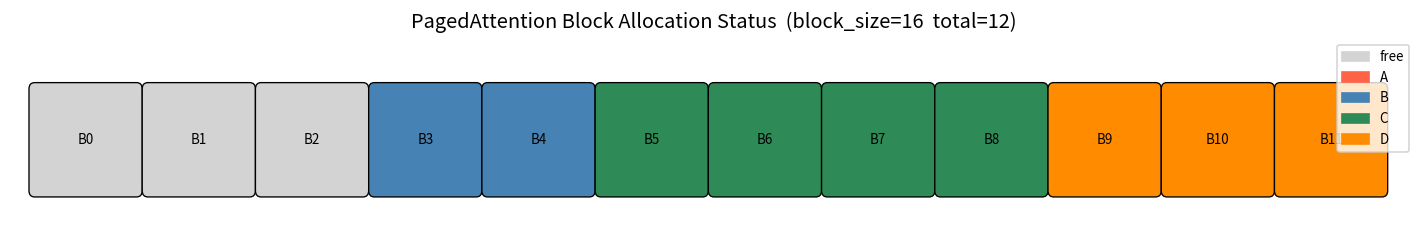

In [7]:
from collections import deque

@dataclass
class KVBlock:
    block_id: int
    ref_count: int = 0
    token_ids: list = field(default_factory=list)
    block_hash: Optional[int] = None   # for Prefix Caching


class BlockPool:
    """Simplified simulation of vLLM KVCacheBlock / FreeKVCacheBlockQueue"""

    def __init__(self, num_blocks: int, block_size: int):
        self.block_size = block_size
        self.blocks = [KVBlock(i) for i in range(num_blocks)]
        # Free block queue (FIFO; vLLM uses doubly-linked list for O(1))
        self.free_queue: deque[KVBlock] = deque(self.blocks)
        self.hash_to_block: dict[int, KVBlock] = {}   # for Prefix Caching
        self.log = []

    def allocate(self, req_id: str, token_ids: list) -> list[KVBlock]:
        needed = (len(token_ids) + self.block_size - 1) // self.block_size
        if len(self.free_queue) < needed:
            raise MemoryError(f"OOM: need {needed} blocks, have {len(self.free_queue)}")
        allocated = []
        for i in range(needed):
            blk = self.free_queue.popleft()
            start = i * self.block_size
            blk.token_ids = token_ids[start:start + self.block_size]
            blk.ref_count = 1
            allocated.append(blk)
        self.log.append(f"alloc req={req_id}: blocks {[b.block_id for b in allocated]}")
        return allocated

    def free(self, req_id: str, blocks: list[KVBlock]):
        freed_ids = []
        for blk in blocks:
            blk.ref_count -= 1
            if blk.ref_count == 0:
                blk.token_ids = []
                blk.block_hash = None
                self.free_queue.append(blk)
                freed_ids.append(blk.block_id)
        self.log.append(f"free  req={req_id}: blocks {freed_ids} -> free pool")

    @property
    def free_count(self):
        return len(self.free_queue)


# --- Simulation ---
TOTAL_BLOCKS = 12
BLOCK_SIZE   = 16

pool = BlockPool(TOTAL_BLOCKS, BLOCK_SIZE)
print(f"Initial free blocks: {pool.free_count}/{TOTAL_BLOCKS}")

# Request A: 40 tokens -> 3 blocks
req_a_tokens = list(range(40))
blks_a = pool.allocate("A", req_a_tokens)
print(f"After req A allocation: free {pool.free_count}")

# Request B: 20 tokens -> 2 blocks
req_b_tokens = list(range(100, 120))
blks_b = pool.allocate("B", req_b_tokens)
print(f"After req B allocation: free {pool.free_count}")

# Request C: 64 tokens -> 4 blocks
req_c_tokens = list(range(200, 264))
blks_c = pool.allocate("C", req_c_tokens)
print(f"After req C allocation: free {pool.free_count}")

# req A done -> free
pool.free("A", blks_a)
print(f"After req A freed:      free {pool.free_count}")

# Allocate new request D to freed blocks
req_d_tokens = list(range(300, 348))
blks_d = pool.allocate("D", req_d_tokens)
print(f"After req D allocation: free {pool.free_count}")

print()
print("Operation log:")
for entry in pool.log:
    print(" ", entry)

# --- Visualize block usage ---
# Display state of each block as a heatmap-style chart
all_reqs = {"A": blks_a, "B": blks_b, "C": blks_c, "D": blks_d}
state = ["free"] * TOTAL_BLOCKS
for req, blks in all_reqs.items():
    for b in blks:
        if b.ref_count > 0:
            state[b.block_id] = req

fig, ax = plt.subplots(figsize=(12, 2))
color_map = {"free": "lightgray", "A": "tomato", "B": "steelblue", "C": "seagreen", "D": "darkorange"}
for i, s in enumerate(state):
    rect = mpatches.FancyBboxPatch((i, 0), 0.9, 0.8,
                                   boxstyle="round,pad=0.05",
                                   facecolor=color_map[s], edgecolor="black", linewidth=0.8)
    ax.add_patch(rect)
    ax.text(i + 0.45, 0.4, f"B{i}", ha="center", va="center", fontsize=8)

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_handles, loc="upper right", fontsize=8)
ax.set_xlim(-0.2, TOTAL_BLOCKS + 0.2)
ax.set_ylim(-0.2, 1.2)
ax.axis("off")
ax.set_title(f"PagedAttention Block Allocation Status  (block_size={BLOCK_SIZE}  total={TOTAL_BLOCKS})")
plt.tight_layout()
plt.show()

---
## 6. Prefix Caching Hash Chain

vLLM's Prefix Caching **reuses KV at block granularity**.  
Requests sharing the same prefix (e.g., system prompt) only need to increment  
`ref_count` on cached blocks — no recomputation required.

Block hashes use a **chain scheme**:
```python
# vLLM: kv_cache_utils.py  hash_block_tokens()
block_hash = hash((parent_block_hash, tuple(token_ids), extra_keys))
```

This ensures blocks with the same prefix get the same hash value,  
allowing **physical block sharing** across different requests.

=== Block hashes for Request A ===
  Block 0: tokens=(1, 2, 3, 4)  hash=ab91...
  Block 1: tokens=(5, 6, 7, 8)  hash=a027...
  Block 2: tokens=(9, 10, 11, 12)  hash=41bf...
  Block 3: tokens=(101, 102, 103, 104)  hash=a617...

=== Block hashes for Request B ===
  Block 0: tokens=(1, 2, 3, 4)  hash=ab91...
  Block 1: tokens=(5, 6, 7, 8)  hash=a027...
  Block 2: tokens=(9, 10, 11, 12)  hash=41bf...
  Block 3: tokens=(201, 202, 203, 204)  hash=b4d9...

Shareable blocks: 3 / 4
  -> system prompt 12 tokens (3 blocks) can reuse KV cache
  -> user prompt blocks differ in content -> hash mismatch -> recompute required


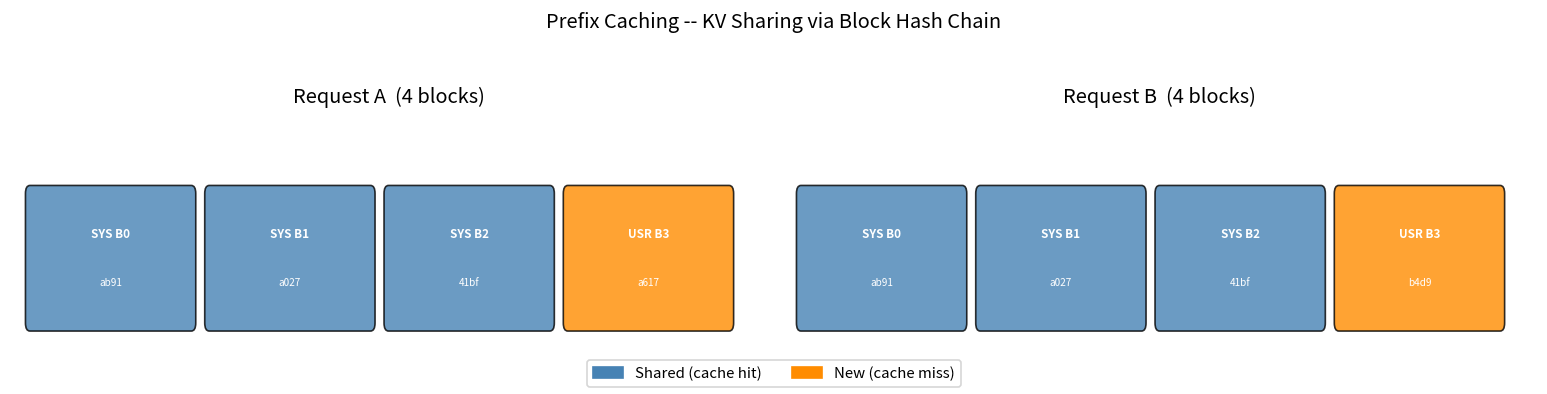

In [8]:
def hash_block_tokens(parent_hash: int, token_ids: tuple, extra_keys: tuple = ()) -> int:
    """Mimics vLLM hash_block_tokens() (implementation uses hashlib)"""
    h = hashlib.sha256()
    h.update(str((parent_hash, token_ids, extra_keys)).encode())
    return int(h.hexdigest()[:16], 16)  # truncate to 64 bits


BLOCK_SIZE = 4   # small for illustration
INIT_HASH  = 0   # parent hash of root block

def compute_prefix_hashes(token_ids: list[int], block_size: int = BLOCK_SIZE) -> list[dict]:
    """Split token sequence into blocks and compute chain hash for each block"""
    blocks = []
    parent_hash = INIT_HASH
    for start in range(0, len(token_ids), block_size):
        chunk = tuple(token_ids[start:start + block_size])
        if len(chunk) < block_size:
            break  # incomplete last block excluded from cache (vLLM spec)
        bh = hash_block_tokens(parent_hash, chunk)
        blocks.append({"tokens": chunk, "parent_hash": parent_hash, "block_hash": bh})
        parent_hash = bh
    return blocks


# 2 requests with shared system prompt + unique user prompts
SYSTEM_TOKENS = [1, 2, 3, 4,  5, 6, 7, 8,  9, 10, 11, 12]  # 12 tokens = 3 blocks
USER_A_TOKENS = [101, 102, 103, 104]                          # 1 block
USER_B_TOKENS = [201, 202, 203, 204]                          # 1 block (different content)

tokens_A = SYSTEM_TOKENS + USER_A_TOKENS
tokens_B = SYSTEM_TOKENS + USER_B_TOKENS

hashes_A = compute_prefix_hashes(tokens_A)
hashes_B = compute_prefix_hashes(tokens_B)

print("=== Block hashes for Request A ===")
for i, b in enumerate(hashes_A):
    print(f"  Block {i}: tokens={b['tokens']}  hash={b['block_hash'] & 0xFFFF:04x}...")

print()
print("=== Block hashes for Request B ===")
for i, b in enumerate(hashes_B):
    print(f"  Block {i}: tokens={b['tokens']}  hash={b['block_hash'] & 0xFFFF:04x}...")

# Hash match check
print()
shared = sum(1 for a, b in zip(hashes_A, hashes_B) if a["block_hash"] == b["block_hash"])
print(f"Shareable blocks: {shared} / {max(len(hashes_A), len(hashes_B))}")
print(f"  -> system prompt {len(SYSTEM_TOKENS)} tokens ({shared} blocks) can reuse KV cache")
print(f"  -> user prompt blocks differ in content -> hash mismatch -> recompute required")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 3))

for ax, hashes, label in [(axes[0], hashes_A, "Request A"), (axes[1], hashes_B, "Request B")]:
    for i, b in enumerate(hashes):
        is_shared = (i < shared)
        color = "steelblue" if is_shared else "darkorange"
        rect = mpatches.FancyBboxPatch((i * 2, 0), 1.8, 0.8,
                                       boxstyle="round,pad=0.05",
                                       facecolor=color, edgecolor="black", alpha=0.8)
        ax.add_patch(rect)
        tag = "SYS" if is_shared else "USR"
        ax.text(i * 2 + 0.9, 0.55, f"{tag} B{i}", ha="center", va="center",
                fontsize=7, color="white", fontweight="bold")
        ax.text(i * 2 + 0.9, 0.25, f"{b['block_hash'] & 0xFFFF:04x}", ha="center",
                va="center", fontsize=6, color="white")
    ax.set_xlim(-0.2, len(hashes) * 2 + 0.2)
    ax.set_ylim(-0.3, 1.3)
    ax.axis("off")
    ax.set_title(f"{label}  ({len(hashes)} blocks)")

shared_patch  = mpatches.Patch(color="steelblue",  label="Shared (cache hit)")
new_patch     = mpatches.Patch(color="darkorange", label="New (cache miss)")
fig.legend(handles=[shared_patch, new_patch], loc="lower center", ncol=2, fontsize=9)
plt.suptitle("Prefix Caching -- KV Sharing via Block Hash Chain", y=1.05)
plt.tight_layout()
plt.show()

---
## 7. Effect of KV Cache Quantization

Quantization modes supported by vLLM's `KVQuantMode`:

| Mode | dtype | Precision | Memory Reduction |
|---|---|---|---|
| NONE | bfloat16 / float16 | Baseline | 1x |
| FP8_PER_TENSOR | FP8 E4M3 | Nearly identical | **2x** |
| INT8_PER_TOKEN_HEAD | INT8 + scale | Slight degradation | **2x** |
| NVFP4 | FP4 E2M1 | Experimental | **4x** |

transformers' `QuantizedCache` (KIVI algorithm) takes a different approach:
- Older tokens → 4-bit compressed
- Most recent `residual_length=128` tokens → kept at 16-bit (maintains Attention accuracy)

Method                       RMSE  Memory (KB) Reduction
----------------------------------------------------------
FP16 (baseline)                --         64.0     1.0x
FP8 (per-tensor)         0.316075         32.0      2.0x
INT8 (per-token)         0.006481         33.0      1.9x
KIVI (res=32)            0.006066         44.0      1.5x


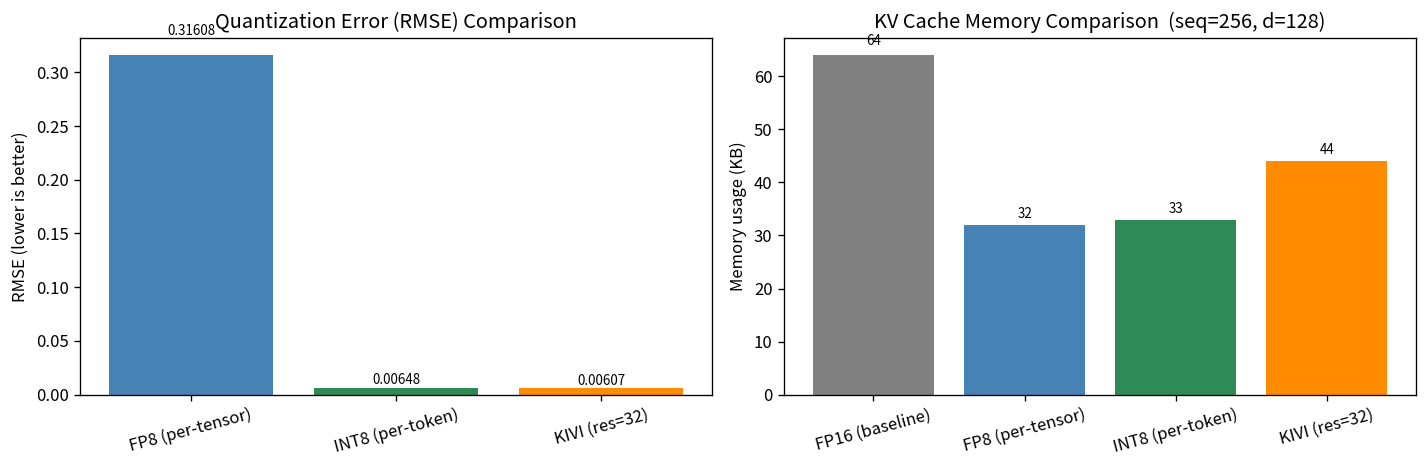

In [9]:
def quantize_fp8(x: np.ndarray) -> tuple[np.ndarray, float]:
    """Simplified simulation of FP8 E4M3 (approximated as scale x 8-bit integer)"""
    scale = np.abs(x).max() / 448.0 + 1e-12   # E4M3 max = 448
    x_q   = np.clip(np.round(x / scale), -128, 127).astype(np.int8)
    return x_q, scale

def dequantize_fp8(x_q: np.ndarray, scale: float) -> np.ndarray:
    return x_q.astype(np.float32) * scale

def quantize_int8_per_token(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """INT8 per-token: scale each row (token) independently"""
    scales = np.abs(x).max(axis=-1, keepdims=True) / 127.0 + 1e-12
    x_q    = np.clip(np.round(x / scales), -128, 127).astype(np.int8)
    return x_q, scales

def dequantize_int8_per_token(x_q: np.ndarray, scales: np.ndarray) -> np.ndarray:
    return x_q.astype(np.float32) * scales

def kivi_quantize(cache: np.ndarray, residual_length: int = 16):
    """KIVI: keep most recent residual_length tokens in fp32, compress the rest to int8"""
    if len(cache) <= residual_length:
        return cache.astype(np.float32), None, None
    old   = cache[:-residual_length]
    recent= cache[-residual_length:]
    scales = np.abs(old).max(axis=-1, keepdims=True) / 127.0 + 1e-12
    old_q  = np.clip(np.round(old / scales), -128, 127).astype(np.int8)
    return recent.astype(np.float32), old_q, scales

def kivi_dequantize(recent, old_q, scales):
    if old_q is None:
        return recent
    old_deq = old_q.astype(np.float32) * scales
    return np.vstack([old_deq, recent])


# --- Simulation of quantization error and memory reduction ---
np.random.seed(7)
SEQ, D = 256, 128
cache_fp16 = np.random.randn(SEQ, D).astype(np.float16)

# FP8
fp8_q, fp8_scale = quantize_fp8(cache_fp16.astype(np.float32))
fp8_deq = dequantize_fp8(fp8_q, fp8_scale)

# INT8 per-token
int8_q, int8_scales = quantize_int8_per_token(cache_fp16.astype(np.float32))
int8_deq = dequantize_int8_per_token(int8_q, int8_scales)

# KIVI (residual_length=32)
RESIDUAL = 32
recent, old_q, old_scales = kivi_quantize(cache_fp16.astype(np.float32), RESIDUAL)
kivi_deq = kivi_dequantize(recent, old_q, old_scales)

# Error calculation
def rmse(a, b):
    return np.sqrt(np.mean((a.astype(np.float32) - b) ** 2))

orig = cache_fp16.astype(np.float32)
errors = {
    "FP8 (per-tensor)":   rmse(orig, fp8_deq),
    "INT8 (per-token)":   rmse(orig, int8_deq),
    f"KIVI (res={RESIDUAL})": rmse(orig, kivi_deq),
}

# Memory reduction (FP16 baseline = 2 bytes/element)
baseline_bytes = SEQ * D * 2
memory = {
    "FP16 (baseline)":    baseline_bytes,
    "FP8 (per-tensor)":   SEQ * D * 1,           # 1 byte/elem
    "INT8 (per-token)":   SEQ * D * 1 + SEQ * 4, # int8 + per-token scale (float32)
    f"KIVI (res={RESIDUAL})": (SEQ - RESIDUAL) * D * 1 + RESIDUAL * D * 4,
}

print(f"{'Method':<22} {'RMSE':>10} {'Memory (KB)':>12} {'Reduction':>8}")
print("-" * 58)
print(f"{'FP16 (baseline)':<22} {'--':>10} {baseline_bytes/1024:>12.1f} {'1.0x':>8}")
for name, err in errors.items():
    mem = memory[name]
    ratio = baseline_bytes / mem
    print(f"{name:<22} {err:>10.6f} {mem/1024:>12.1f} {ratio:>8.1f}x")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE bar chart
names  = list(errors.keys())
values = list(errors.values())
bars = axes[0].bar(names, values, color=["steelblue", "seagreen", "darkorange"])
axes[0].set_ylabel("RMSE (lower is better)")
axes[0].set_title("Quantization Error (RMSE) Comparison")
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v * 1.05, f"{v:.5f}",
                 ha="center", va="bottom", fontsize=8)

# Memory usage bar chart
all_names = list(memory.keys())
all_mem   = [m / 1024 for m in memory.values()]
colors    = ["gray", "steelblue", "seagreen", "darkorange"]
bars2 = axes[1].bar(all_names, all_mem, color=colors)
axes[1].set_ylabel("Memory usage (KB)")
axes[1].set_title(f"KV Cache Memory Comparison  (seq={SEQ}, d={D})")
axes[1].tick_params(axis='x', rotation=15)
for bar, m in zip(bars2, all_mem):
    axes[1].text(bar.get_x() + bar.get_width()/2, m * 1.02, f"{m:.0f}",
                 ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()